# Model Training & Evaluation 

This notebook serves understand better the steps needed for model training after data is split and scaled. We assume the dataset has already been prepared previously (label construction, feature engineering, one-hot encoding). 

Here we focus entirely on the **modeling stage** of the ML workflow: no data exploration or feature construction.

## Section 1 — Introduction

**Session 1** built the dataset: we have features (RFM, one-hot encoded categoricals, etc.) and a target label (`future_revenue_90d`). We do **not** redo data exploration or feature engineering here.

**Session 2** focuses on the **modeling pipeline**:

1. **Split strategy** — Reserve a hold-out test set for final evaluation.
2. **Baseline** — Establish simple benchmarks (e.g. mean prediction, linear model).
3. **Metrics** — Use MAE, RMSE, and R² for regression evaluation.
4. **Cross-validation** — Get more reliable performance estimates than a single train/test split.
5. **Learning curves** — Plot train vs validation error as a function of training set size to diagnose underfitting/overfitting and whether more data would help.
6. **Model comparison** — Compare several algorithms (Ridge, Lasso, tree-based) via CV.
7. **Hyperparameter tuning** — Use grid search to select good hyperparameters (with care to avoid overfitting).
8. **Train/validation development & early stopping** — For iterative models (e.g. gradient boosting), observe train vs validation error over iterations and stop at the best validation step instead of overfitting.
9. **Feature selection** — After we have a chosen, tuned model, we select a subset of features (on the training set only) using that model's importance or a wrapper; this reduces overfitting and simplifies the pipeline.
10. **Final test evaluation** — Evaluate the chosen model (trained on selected features) once on the held-out test set and interpret results (e.g. predictions vs actuals, feature importance).

## Section 2 — Load Dataset (pre-split, pre-scaled)

We load the **already prepared training inputs** exported at the end of Session 1. The project root is set so the notebook works whether you run it from the repo root or from inside `notebooks/`.

**What we load (from `data/`)**

- `X_train_scaled.csv`, `y_train.csv`
- `X_val_scaled.csv`, `y_val.csv`
- `feature_columns.csv` (to enforce a stable feature order)

**Why this is useful:** we can start model training immediately with a leakage-safe setup because scaling was fit on the training split only (Session 1) and then applied to both splits.

In [1]:
# --- Imports and path setup ---
# We need the project root so that data path works from repo root or from notebooks/
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import SelectFromModel

# Project root: if "data" not under cwd, assume we're in notebooks/ and go up
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"

# Set seed for reproducibility 
SEED = 42

In [2]:
# ---------------------------------------------------------------------------
# Load the **pre-split and preprocessed** datasets produced in Session 1
# ---------------------------------------------------------------------------
# Session 1 exports:
# - X_train_scaled.csv, X_val_scaled.csv (scaled feature matrices)
# - y_train.csv, y_val.csv (targets)
# - feature_columns.csv (feature order)

feature_cols_path = DATA_DIR / "feature_columns.csv"
X_train_path = DATA_DIR / "X_train_scaled.csv"
X_test_path = DATA_DIR / "X_val_scaled.csv"
y_train_path = DATA_DIR / "y_train.csv"
y_test_path = DATA_DIR / "y_val.csv"


In [3]:

FEATURE_COLS = pd.read_csv(feature_cols_path)["feature_name"].tolist()

X_train = pd.read_csv(X_train_path)
X_test = pd.read_csv(X_test_path)

y_train = pd.read_csv(y_train_path).iloc[:, 0]
y_test = pd.read_csv(y_test_path).iloc[:, 0]

# Enforce consistent column order (and protect against accidental reordering)
X_train = X_train[FEATURE_COLS]
X_test = X_test[FEATURE_COLS]

TARGET = "future_revenue_90d"

print("Loaded pre-split, scaled datasets from:")
print(" -", X_train_path)
print(" -", X_test_path)
print(" -", y_train_path)
print(" -", y_test_path)
print("Number of features:", len(FEATURE_COLS))
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test:", X_test.shape, "| y_test:", y_test.shape)

Loaded pre-split, scaled datasets from:
 - /Users/minye/Documents/gitHub/ainvone/cusy-gfu/gfu/schulung-ki_von_grund_auf/01-Einfuehrung-in-KI/docs/1intro/data/X_train_scaled.csv
 - /Users/minye/Documents/gitHub/ainvone/cusy-gfu/gfu/schulung-ki_von_grund_auf/01-Einfuehrung-in-KI/docs/1intro/data/X_val_scaled.csv
 - /Users/minye/Documents/gitHub/ainvone/cusy-gfu/gfu/schulung-ki_von_grund_auf/01-Einfuehrung-in-KI/docs/1intro/data/y_train.csv
 - /Users/minye/Documents/gitHub/ainvone/cusy-gfu/gfu/schulung-ki_von_grund_auf/01-Einfuehrung-in-KI/docs/1intro/data/y_val.csv
Number of features: 17
X_train: (960, 17) | y_train: (960,)
X_test: (240, 17) | y_test: (240,)


In [4]:
# Quick inspection (these are already features-only matrices, scaled)
print("X_train (scaled) shape:", X_train.shape)
print("X_test (scaled) shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

display(X_train.head())
display(y_train.head())

X_train (scaled) shape: (960, 17)
X_test (scaled) shape: (240, 17)
y_train shape: (960,)
y_test shape: (240,)


,country_DE,country_ES,country_FR,country_IT,customer_segment_Premium,customer_segment_Standard,acquisition_channel_Organic,acquisition_channel_Paid Ads,acquisition_channel_Referral,recency_days,frequency,monetary_total,avg_order_value,recent_30d_spend,prev_30d_spend,spend_trend,tenure_days
0,-0.574143,-0.521079,1.974325,-0.483666,-0.408,1.062357,1.332129,-0.656278,-0.477097,-1.243983,0.324130,-0.109856,-0.025927,0.361598,-0.202790,0.330898,0.451772
1,-0.574143,-0.521079,-0.506502,-0.483666,-0.408,-0.941303,1.332129,-0.656278,-0.477097,-0.858878,0.955295,0.166573,0.032016,-0.331379,0.234555,-0.348523,1.695356
2,-0.574143,1.919095,-0.506502,-0.483666,-0.408,-0.941303,1.332129,-0.656278,-0.477097,0.168067,-0.307036,-0.162731,0.423502,-0.331379,-0.202790,0.057988,0.594713
3,-0.574143,-0.521079,-0.506502,2.067541,-0.408,1.062357,-0.750678,1.523745,-0.477097,-1.215457,0.324130,0.208202,0.417439,2.039100,-0.017451,0.819264,0.189714
4,-0.574143,-0.521079,1.974325,-0.483666,-0.408,-0.941303,-0.750678,-0.656278,2.096010,0.710066,-0.307036,-0.331547,-0.047147,-0.331379,-0.202790,0.057988,0.532772


0    46.63
1     0.00
2     9.05
3    76.17
4     0.00
Name: future_revenue_90d, dtype: float64

In [5]:
# Targets are already loaded as y_train/y_test; feature matrices are already scaled.
# We still report target stats for context (revenue is often right-skewed with many zeros).

print("Number of features:", X_train.shape[1])
print("Target stats (train) — min: {:.2f}, median: {:.2f}, max: {:.2f}".format(
    y_train.min(), y_train.median(), y_train.max()))

pct_zeros_train = (y_train == 0).mean() * 100
pct_zeros_test = (y_test == 0).mean() * 100
print("Percent of zeros in target (train): {:.1f}%".format(pct_zeros_train))
print("Percent of zeros in target (test):  {:.1f}%".format(pct_zeros_test))

Number of features: 17
Target stats (train) — min: 0.00, median: 18.66, max: 1070.01
Percent of zeros in target (train): 45.6%
Percent of zeros in target (test):  43.3%


## Section 3 — Train/Test Split (already done upstream)

In **Session 1**, we already:

- built the feature matrix,
- performed redundancy handling,
- did the **train/validation split**, and
- fit scaling on **training** data only, then transformed both splits.

This notebook therefore **loads**:

- `X_train_scaled.csv`, `y_train.csv`
- `X_val_scaled.csv`, `y_val.csv`

and treats `X_val_scaled`/`y_val` as the **held-out test set** for final evaluation.

**Why this is good practice:** it keeps the test set untouched during model selection and avoids leakage from scaling/feature selection into evaluation.

### Evaluation design in a nutshell

Our evaluation follows a single, clear principle: **the test set is used exactly once**, at the end, to report final performance. Everything else happens on the training set:

| Step | Where it happens | Purpose |
|------|------------------|--------|
| Train/test split | Once at the start | Reserve an untouched test set for final reporting. |
| Baselines | Trained on train, evaluated on test | Establish a reference; we accept this one use of test for baselines so we can compare the final model to a trivial benchmark. |
| Cross-validation | On training set only | Compare models and tune hyperparameters without touching the test set. |
| Model selection & tuning | Via CV on train | Pick the best model and hyperparameters using only train/validation splits. |
| Feature selection | On training set only (after tuning) | Choose a subset of features using the tuned model's importance (or a wrapper); refit and evaluate on test with selected features only. |
| **Final evaluation** | **Once on test set** | Report MAE, RMSE, R² (and plots) as the unbiased estimate of generalization. |

So: we **never** use the test set to choose a model or a hyperparameter. That way, test metrics are a valid estimate of how the chosen pipeline will perform on new data.

In [6]:
# Train/test split has already been performed in Session 1; we loaded X_train/X_test above.
# We just re-print shapes here for convenience.
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test:", X_test.shape, "| y_test:", y_test.shape)

X_train: (960, 17) | y_train: (960,)
X_test: (240, 17) | y_test: (240,)


In [7]:
# ---------------------------------------------------------------------------
# Scaling note
# ---------------------------------------------------------------------------
# Scaling has already been applied in Session 1 and exported as X_train_scaled.csv / X_val_scaled.csv.
# In this notebook we therefore train directly on X_train (scaled) and evaluate on X_test (scaled).
#
# If you want to re-fit preprocessing inside this notebook instead, load the raw splits
# (X_train.csv / X_val.csv) and fit the scaler on X_train only.

print("Using pre-scaled feature matrices.")
print("X_train dtype summary:")
display(X_train.dtypes.value_counts())

Using pre-scaled feature matrices.
X_train dtype summary:


float64    17
Name: count, dtype: int64

## Section 4 — Baseline Models

**Why baselines matter:** Before using complex models, we need a reference. A baseline (e.g. predicting the mean, or a simple linear model) tells us whether our features and models add value. If a sophisticated model cannot beat a trivial baseline, we should reconsider the problem or the features.

**Why these metrics (MAE, RMSE, R²)?** We report three regression metrics so that we can interpret both *magnitude* and *scale-free* performance: **MAE** (mean absolute error) is the average error in the same units as the target (e.g. euros)—easy to communicate and robust to outliers. **RMSE** (root mean squared error) also has target units but penalizes large errors more; it is useful when big mistakes are especially costly. **R²** (coefficient of determination) is the fraction of variance in the target explained by the model (0 = no better than predicting the mean; 1 = perfect). Reporting all three gives a fuller picture than a single number.

**Interpreting the table:** The **Dummy (mean)** regressor predicts the average of `y_train` for every test point; its R² is typically near 0 (or slightly negative). **LinearRegression** should do a bit better (lower MAE/RMSE, higher R²) if the features carry signal. If LinearRegression is only marginally better than the dummy, that suggests either limited predictive signal in the features or that the problem is inherently hard (e.g. noisy target).

In [8]:
# Baseline A: predict the training mean for every test sample (no use of X_test features)
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

# Baseline B: ordinary least-squares linear regression using all features
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

def eval_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

results_baseline = pd.DataFrame({
    "Dummy (mean)": eval_metrics(y_test, y_pred_dummy),
    "LinearRegression": eval_metrics(y_test, y_pred_lr),
}).T
print("Baseline results on test set:")
display(results_baseline)

Baseline results on test set:


,MAE,RMSE,R2
Dummy (mean),46.247892,66.807927,-0.002711
LinearRegression,45.174727,65.755370,0.028636


## Section 5 — Cross-Validation

A single train/test split can be noisy. **Cross-validation** (e.g. 5-fold) trains and evaluates the model on different splits and reports the mean and standard deviation of the metric. This gives a more reliable estimate of performance and reduces the risk of overfitting to one particular split. 

**Why 5-fold?** Five folds are a common default, esp. for a smaller dataset: each fold leaves 20% out for validation, so we get five different train/validation splits and average the metric—more stable than a single split, without the higher cost of 10-fold CV.

**Outcome:** The printed CV RMSE is the average over 5 folds. Note that this is computed on the **training** set only (each fold has its own train/validation split). The mean gives a more stable performance estimate than the single test split we did for baselines; the standard deviation indicates how much the metric varies across folds. If std is high, performance is sensitive to the split.

In [9]:
# 5-fold CV on training data only; sklearn uses neg RMSE so we negate to get positive RMSE
kfold = KFold(n_splits=5, shuffle=True, random_state=SEED)
scores_rmse = cross_val_score(
    LinearRegression(), X_train, y_train,
    cv=kfold, scoring="neg_root_mean_squared_error"
)
rmse_cv = -scores_rmse  # convert to positive RMSE
print("LinearRegression — 5-fold CV RMSE: {:.4f} ± {:.4f}".format(
    rmse_cv.mean(), rmse_cv.std()))

LinearRegression — 5-fold CV RMSE: 81.2037 ± 8.8965


## Section 5b — Learning Curves: Train vs Validation by Data Size

So far we have looked at a single metric (e.g. CV RMSE) for a fixed training set. **Learning curves** show how **training error** and **validation error** change as we vary the **size of the training set**. This helps answer:

- **Underfitting**: If both train and validation error are high and close, the model may be too simple or need more data.
- **Overfitting**: If training error is much lower than validation error, the model is fitting the training data too closely.
- **More data?**: If validation error is still decreasing at the right end of the curve, more data might help.

We define a helper that wraps sklearn's `learning_curve`: it trains on increasing subsets of the data and reports mean train and validation score (here, RMSE) with standard deviation bands.

**Interpreting the plot:** Typically, train RMSE decreases as we use more data (the model fits the training set better), while validation RMSE often starts high and then decreases. A large gap between the two curves at the right suggests overfitting; curves that are close and high suggest underfitting or that the model is already at its capacity.

In [10]:
"""
Helpers for plotting training vs validation behaviour (learning curves and
train/val development over iterations). Used in the Session 2 notebook to
teach overfitting, underfitting, and early stopping.
"""
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.metrics import mean_squared_error


def plot_learning_curve(
    estimator,
    X,
    y,
    *,
    cv=5,
    train_sizes=None,
    scoring="neg_root_mean_squared_error",
    ax=None,
    title="Learning curve (train vs validation)",
):
    """
    Plot learning curve: mean train and validation score vs training set size.

    Uses sklearn's learning_curve. For RMSE we use neg_root_mean_squared_error;
    the plot shows positive RMSE (converted from negative scores).

    Parameters
    ----------
    estimator : sklearn estimator
    X, y : feature matrix and target
    cv : int or CV splitter
    train_sizes : array-like, optional
        Relative or absolute numbers of training examples. Default: np.linspace(0.1, 1.0, 10).
    scoring : str
        Sklearn scorer name. Default neg_root_mean_squared_error (we convert to positive for plot).
    ax : matplotlib axes, optional
    title : str

    Returns
    -------
    ax
    """
    if train_sizes is None:
        train_sizes = np.linspace(0.1, 1.0, 10)
    train_sizes_abs, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, train_sizes=train_sizes, scoring=scoring, n_jobs=-1
    )
    # sklearn returns negative RMSE; convert to positive for display
    sign = -1 if scoring.startswith("neg_") else 1
    train_scores = sign * train_scores
    test_scores = sign * test_scores
    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    test_mean = test_scores.mean(axis=1)
    test_std = test_scores.std(axis=1)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    ax.fill_between(
        train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.2
    )
    ax.fill_between(
        train_sizes_abs, test_mean - test_std, test_mean + test_std, alpha=0.2
    )
    ax.plot(train_sizes_abs, train_mean, "o-", label="Train (RMSE)")
    ax.plot(train_sizes_abs, test_mean, "o-", label="Validation (RMSE)")
    ax.set_xlabel("Training set size")
    ax.set_ylabel("RMSE")
    ax.set_title(title)
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3)
    return ax


def compute_gbr_staged_rmse(
    X_train,
    y_train,
    X_val,
    y_val,
    n_estimators=200,
    random_state=42,
    **kwargs,
):
    """
    Fit a GradientBoostingRegressor with n_estimators and return train/val RMSE
    at each boosting stage (1, 2, ..., n_estimators).

    Uses staged_predict for efficiency (single fit, then iterate predictions).

    Parameters
    ----------
    X_train, y_train : training data
    X_val, y_val : validation data
    n_estimators : int
    random_state : int
    **kwargs : passed to GradientBoostingRegressor (e.g. max_depth, learning_rate).

    Returns
    -------
    steps : np.ndarray of shape (n_estimators,), 1..n_estimators
    train_rmse : np.ndarray of shape (n_estimators,)
    val_rmse : np.ndarray of shape (n_estimators,)
    model : fitted GradientBoostingRegressor (with n_estimators trees)
    """
    from sklearn.ensemble import GradientBoostingRegressor

    model = GradientBoostingRegressor(
        n_estimators=n_estimators, random_state=random_state, **kwargs
    )
    model.fit(X_train, y_train)

    train_rmse = []
    for y_pred in model.staged_predict(X_train):
        train_rmse.append(np.sqrt(mean_squared_error(y_train, y_pred)))
    val_rmse = []
    for y_pred in model.staged_predict(X_val):
        val_rmse.append(np.sqrt(mean_squared_error(y_val, y_pred)))

    steps = np.arange(1, n_estimators + 1, dtype=int)
    return steps, np.array(train_rmse), np.array(val_rmse), model


def early_stop_index(val_scores, patience=0):
    """
    Index at which validation score is best (for early stopping).

    For RMSE/loss, "best" is minimum. If patience > 0, returns the first index
    after which the validation score did not improve for `patience` consecutive
    steps (optional more realistic early stopping).

    Parameters
    ----------
    val_scores : array-like, e.g. validation RMSE per step
    patience : int
        If > 0: stop when no improvement for this many steps. If 0: simply argmin.

    Returns
    -------
    int : index (0-based) at which to stop
    """
    val_scores = np.asarray(val_scores)
    best_idx = 0
    best_val = val_scores[0]
    for i in range(1, len(val_scores)):
        if val_scores[i] < best_val:
            best_val = val_scores[i]
            best_idx = i
        if patience > 0 and (i - best_idx) >= patience:
            return best_idx
    return best_idx


def plot_train_val_development(
    steps,
    train_scores,
    val_scores,
    early_stop_idx=None,
    *,
    xlabel="Number of boosting iterations",
    ylabel="RMSE",
    title="Train vs validation error development",
    ax=None,
):
    """
    Plot train and validation score (e.g. RMSE) vs step (e.g. n_estimators).
    Optionally mark the early-stopping step.

    Parameters
    ----------
    steps : array-like, e.g. [1, 2, ..., 200]
    train_scores, val_scores : array-like, same length as steps
    early_stop_idx : int or None
        Index (0-based) at which early stopping would occur; draw a vertical line.
    xlabel, ylabel, title : str
    ax : matplotlib axes, optional

    Returns
    -------
    ax
    """
    steps = np.asarray(steps)
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(steps, train_scores, label="Train", color="C0")
    ax.plot(steps, val_scores, label="Validation", color="C1")
    if early_stop_idx is not None and 0 <= early_stop_idx < len(steps):
        ax.axvline(
            steps[early_stop_idx],
            color="gray",
            linestyle="--",
            alpha=0.8,
            label=f"Early stop (step {steps[early_stop_idx]})",
        )
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3)
    return ax


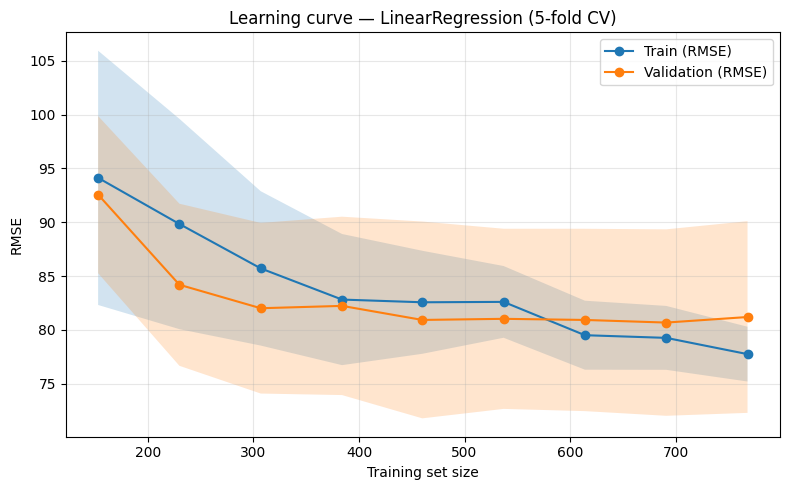

In [11]:
# Ensure project root is on path so we can import from utils
import sys
sys.path.insert(0, str(PROJECT_ROOT))

# Learning curve for LinearRegression on the training set only (no test set used)
# train_sizes from 20% to 100% of X_train in 9 steps
plot_learning_curve(
    LinearRegression(),
    X_train,
    y_train,
    cv=KFold(5, shuffle=True, random_state=SEED),
    train_sizes=np.linspace(0.2, 1.0, 9),
    scoring="neg_root_mean_squared_error",
    title="Learning curve — LinearRegression (5-fold CV)",
)
plt.tight_layout()
plt.show()

## Section 6 — Model Comparison

We compare several models using 5-fold CV on the **training set** only. Included:

- **Ridge** — L2 regularization; shrinks coefficients.
- **Lasso** — L1 regularization; can drive some coefficients to zero (sparsity), which helps interpretability and can reduce overfitting.
- **DecisionTreeRegressor** — Non-linear, interpretable splits; prone to overfitting without tuning.
- **RandomForestRegressor** — Ensemble of trees; typically stronger and more stable than a single tree.

**Interpreting the table:** Compare `mean_RMSE` (and optionally `mean_MAE`) across models. The model with the lowest mean RMSE is the best performer in CV. Random forest often wins on tabular data; if DecisionTree is much worse than RandomForest, that suggests the single tree is overfitting. Ridge and Lasso help when features are correlated or numerous relative to sample size.

In [12]:
# Define models with fixed seeds for reproducibility. Ridge/Lasso use default or mild regularization.
models = {
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01),
    "DecisionTree": DecisionTreeRegressor(random_state=SEED),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=SEED),
}
kfold = KFold(n_splits=5, shuffle=True, random_state=SEED)
rows = []
for name, model in models.items():
    rmse_scores = -cross_val_score(
        model, X_train, y_train, cv=kfold, scoring="neg_root_mean_squared_error"
    )
    mae_scores = -cross_val_score(
        model, X_train, y_train, cv=kfold, scoring="neg_mean_absolute_error"
    )
    rows.append({
        "model_name": name,
        "mean_RMSE": rmse_scores.mean(),
        "std_RMSE": rmse_scores.std(),
        "mean_MAE": mae_scores.mean(),
    })
comparison = pd.DataFrame(rows)
print("Model comparison (5-fold CV on train set):")
display(comparison)

Model comparison (5-fold CV on train set):


,model_name,mean_RMSE,std_RMSE,mean_MAE
0,Ridge,81.181349,8.908445,49.383988
1,Lasso,81.190558,8.902085,49.392256
2,DecisionTree,111.892680,10.583362,64.544156
3,RandomForest,84.959778,5.981569,51.976574


## Section 7 — Hyperparameter Tuning

We use **GridSearchCV** to search over a small grid of hyperparameters for `RandomForestRegressor`. The best model is chosen by CV performance on the training set. **Important:** The test set must remain untouched until the final evaluation. Tuning too aggressively on validation folds can lead to *hyperparameter overfitting*—the chosen hyperparameters may work well on the CV splits but not generalize. Always report final performance on the held-out test set.

**Outcome:** The first cell prints `best_params_` and the best CV RMSE (positive). The second cell shows the top 5 parameter combinations by rank; you can see how small changes in `max_depth`, `n_estimators`, etc. affect CV score. The best configuration is then used for the final model in Section 8.

In [13]:
# Small grid for speed; in practice you might use RandomizedSearchCV or a larger grid
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
}
grid = GridSearchCV(
    RandomForestRegressor(random_state=SEED),
    param_grid,
    cv=KFold(5, shuffle=True, random_state=SEED),
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV RMSE (positive): {:.4f}".format(-grid.best_score_))

Best params: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best CV RMSE (positive): 81.9548


In [14]:
# Show top 5 configurations from grid search (by rank_test_score); convert negative score to RMSE
cv_results = pd.DataFrame(grid.cv_results_)
top5 = cv_results.nsmallest(5, "rank_test_score")[
    ["params", "mean_test_score", "std_test_score"]
].copy()
top5["mean_test_score"] = -top5["mean_test_score"]
top5 = top5.rename(columns={"mean_test_score": "mean_RMSE", "std_test_score": "std_RMSE"})
print("Top 5 configurations:")
display(top5)

Top 5 configurations:


,params,mean_RMSE,std_RMSE
15,"{'max_depth': 5, 'min_samples_leaf': 2, 'min_s...",81.954780,7.653798
12,"{'max_depth': 5, 'min_samples_leaf': 2, 'min_s...",81.984885,7.612004
13,"{'max_depth': 5, 'min_samples_leaf': 2, 'min_s...",81.990217,7.649633
14,"{'max_depth': 5, 'min_samples_leaf': 2, 'min_s...",82.036437,7.522941
11,"{'max_depth': 5, 'min_samples_leaf': 1, 'min_s...",82.228796,7.332110


## Section 7b — Train vs Validation Development and Early Stopping

When we **tune an iterative model** (e.g. number of trees in gradient boosting), we can record **training error** and **validation error** at each step. This gives a clear picture of overfitting: training error keeps decreasing while validation error may flatten or increase after a point. **Early stopping** means we choose the number of iterations where validation performance is best (or stop when it has not improved for a few steps), instead of always using the maximum.

We use **GradientBoostingRegressor**, which builds trees one at a time. Sklearn provides `staged_predict()` so we can get predictions after 1, 2, …, N trees without refitting. Our helper `utils.model_curves` computes train and validation RMSE at each stage and plots them; we then mark the recommended early-stopping step (argmin of validation RMSE). Optionally, **patience**: stop only when validation has not improved for the last K steps (e.g. `patience=5`), which can avoid stopping at a noisy minimum.

**Interpreting the plot:** Train RMSE usually decreases monotonically as we add trees; validation RMSE often improves then levels off or worsens. The vertical dashed line shows where we would stop (best validation step). Using that number of trees instead of the maximum can reduce overfitting and save computation.

Early stop at iteration: 32 | Best validation RMSE: 95.3662


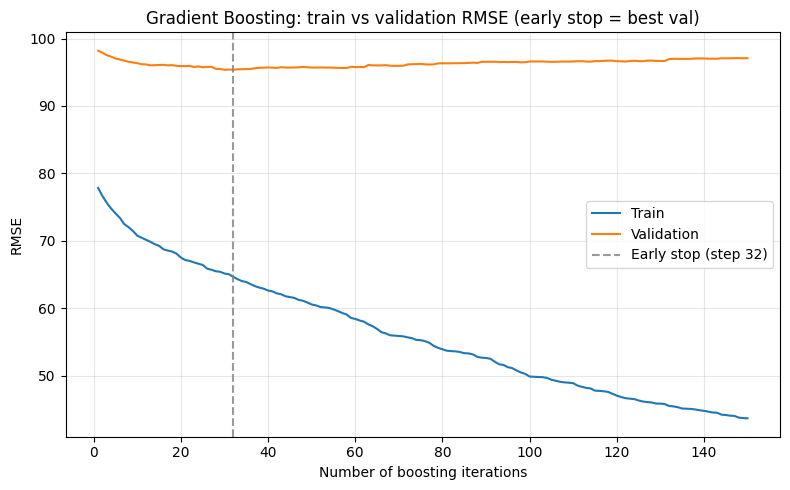

In [15]:
from sklearn.ensemble import GradientBoostingRegressor

# Split training set into train/val for the development curve (test set stays untouched)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=SEED
)
n_estimators = 150  # max number of trees
steps, train_rmse, val_rmse, gbr_model = compute_gbr_staged_rmse(
    X_tr, y_tr, X_val, y_val,
    n_estimators=n_estimators,
    max_depth=3,
    learning_rate=0.1,
    random_state=SEED,
)
# patience=0 means "best val step"; set patience=5 to stop when no improvement for 5 steps
stop_idx = early_stop_index(val_rmse, patience=0)
print("Early stop at iteration:", steps[stop_idx], "| Best validation RMSE: {:.4f}".format(val_rmse[stop_idx]))

plot_train_val_development(
    steps, train_rmse, val_rmse,
    early_stop_idx=stop_idx,
    xlabel="Number of boosting iterations",
    ylabel="RMSE",
    title="Gradient Boosting: train vs validation RMSE (early stop = best val)",
)
plt.tight_layout()
plt.show()

## Section 7c — Feature Selection

After we have a **chosen, tuned model**, we perform **feature selection on the training set only**: we use the tuned model's feature importances (or coefficients) to keep only the most useful features. This reduces overfitting and simplifies the pipeline. We fit a selector on `X_train` and `y_train`, then apply it to both train and test to get `X_train_sel` and `X_test_sel`. The final model (Section 8) is trained and evaluated using these selected features only.

In [16]:
# Use the best estimator from grid search; select features by importance (e.g. threshold='median')
best_estimator = grid.best_estimator_
selector = SelectFromModel(best_estimator, threshold='median')
selector.fit(X_train, y_train)

# Get selected feature names and subset train/test (use .loc to keep column names)
selected = selector.get_support()
X_train_sel = X_train.loc[:, selected]
X_test_sel = X_test.loc[:, selected]
print(f"Selected {X_train_sel.shape[1]} of {X_train.shape[1]} features: {list(X_train_sel.columns)}")

Selected 9 of 17 features: ['country_ES', 'customer_segment_Premium', 'recency_days', 'frequency', 'monetary_total', 'avg_order_value', 'prev_30d_spend', 'spend_trend', 'tenure_days']


## Section 8 — Final Evaluation on Held-out Test Set

We fit the **best estimator** from GridSearchCV on the full training set **using the selected features only** (`X_train_sel`, `y_train`) and evaluate **once** on the test set (`X_test_sel`). This gives an unbiased estimate of generalization. We also plot predicted vs actual: points close to the diagonal indicate good predictions; systematic deviations suggest bias or underfitting/overfitting.

**Why "once"?** By design, we have not used the test set for model choice or tuning. So this is the **only** place we use it for performance—and these test metrics are exactly what we report as our generalization estimate. Using the test set repeatedly (e.g. to pick among models) would leak information and make the estimate optimistic.

**Outcome:** The printed MAE, RMSE, and R² are the *final* numbers you would report. They should be in a similar range to the baseline and CV results; if test performance is much worse than CV, that may indicate overfitting to the validation folds or an unlucky split. The scatter plot shows each test point’s actual value vs predicted value.

In [17]:
# Refit best model on full training set (selected features only), then evaluate once on test set
best_model = grid.best_estimator_
best_model.fit(X_train_sel, y_train)
y_pred = best_model.predict(X_test_sel)

print("Final test set metrics:")
print("  MAE:  {:.4f}".format(mean_absolute_error(y_test, y_pred)))
print("  RMSE: {:.4f}".format(np.sqrt(mean_squared_error(y_test, y_pred))))
print("  R²:   {:.4f}".format(r2_score(y_test, y_pred)))

Final test set metrics:
  MAE:  45.3921
  RMSE: 66.0375
  R²:   0.0203


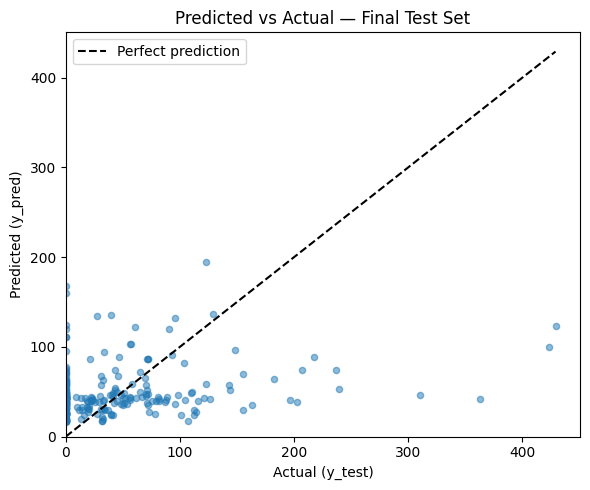

In [18]:
# Predicted vs actual: points on the diagonal are perfect predictions; scatter indicates error magnitude
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_test, y_pred, alpha=0.5, s=20)
max_val = max(y_test.max(), y_pred.max())
ax.plot([0, max_val], [0, max_val], "k--", label="Perfect prediction")
ax.set_xlabel("Actual (y_test)")
ax.set_ylabel("Predicted (y_pred)")
ax.set_title("Predicted vs Actual — Final Test Set")
ax.legend()
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

A good plot has points clustered around the diagonal line. Large scatter or a systematic curve (e.g. under-predicting high values) suggests room for improvement (e.g. different model, features, or target transformation). If points are mostly below the diagonal at high values, the model tends to under-predict revenue; if above, it over-predicts.

## Section 9 — Feature Importance

Random forests provide **feature importances** (e.g. mean decrease in impurity). These are a *global* importance measure and can be biased (e.g. toward high-cardinality or scale-dependent features). In a later session we will cover more robust methods such as **permutation importance** and **SHAP** for interpretability.

**Interpreting the bar chart:** The top 10 features are those that most often reduced impurity when split on. High importance suggests the feature is useful for predictions; it does not tell you the direction of the effect. RFM-style or spend-related features often rank high in revenue prediction; one-hot columns may appear if they separate high/low revenue segments well.

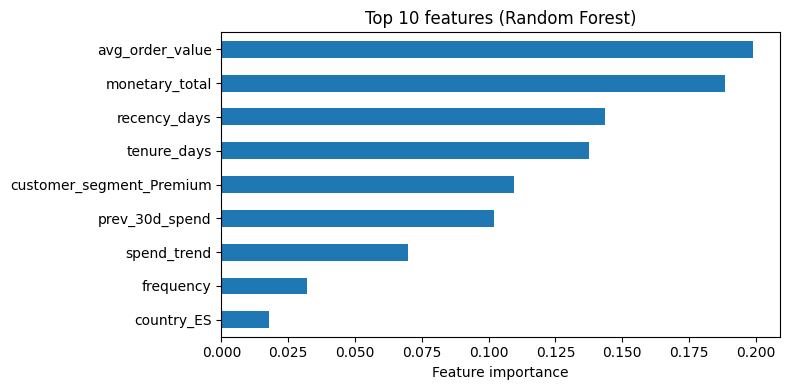

In [19]:
# best_model was fitted on X_train_sel in Section 8; use its feature_importances_ and selected feature names
imp = pd.Series(best_model.feature_importances_, index=X_train_sel.columns).sort_values(ascending=True)
top10 = imp.tail(10)
fig, ax = plt.subplots(figsize=(8, 4))
top10.plot.barh(ax=ax)
ax.set_xlabel("Feature importance")
ax.set_title("Top 10 features (Random Forest)")
plt.tight_layout()
plt.show()

### SHAP: model-agnostic feature importance (global + local)

So far we used the **native feature importances** from the random forest (mean decrease in impurity). These are useful but can be:

- **Model-specific** (not comparable across different algorithms),
- **Biased** towards features with many possible split points (e.g. high-cardinality or continuous features),
- Mostly **global**: they tell you which features matter overall, not how they behave for a *single* prediction.

**SHAP (SHapley Additive exPlanations)** provides:

- **Local explanations**: for a single row, how much each feature pushed the prediction **up or down** from a base value.
- **Global summaries**: by aggregating local SHAP values across many rows.

Reading SHAP plots:

- In **summary plots** (beeswarm): each dot is one row; x-axis is SHAP value (impact on prediction), color encodes feature value (e.g. blue = low, red = high). Features are ordered by overall importance.
- For a **single row** (force/waterfall plot): positive SHAP values push the prediction *up* (towards higher revenue), negative values push it *down*.

Below we compute SHAP values for a sample of the training data using the tuned random forest, and show a global summary plot.

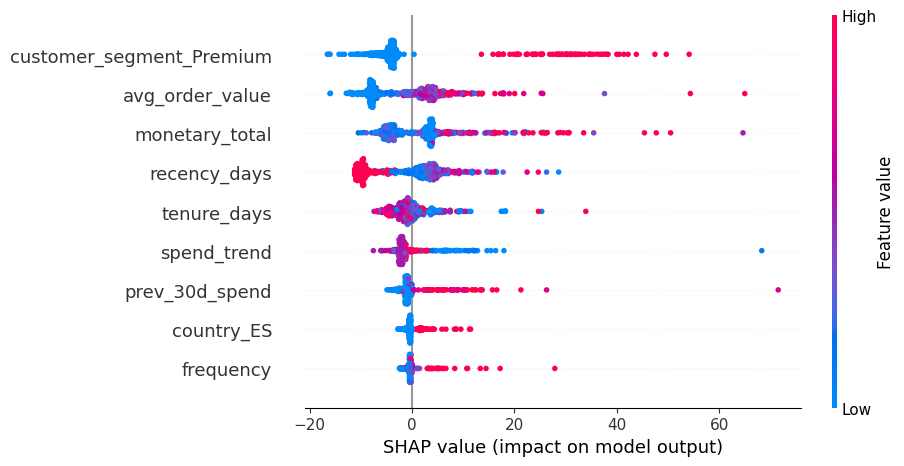

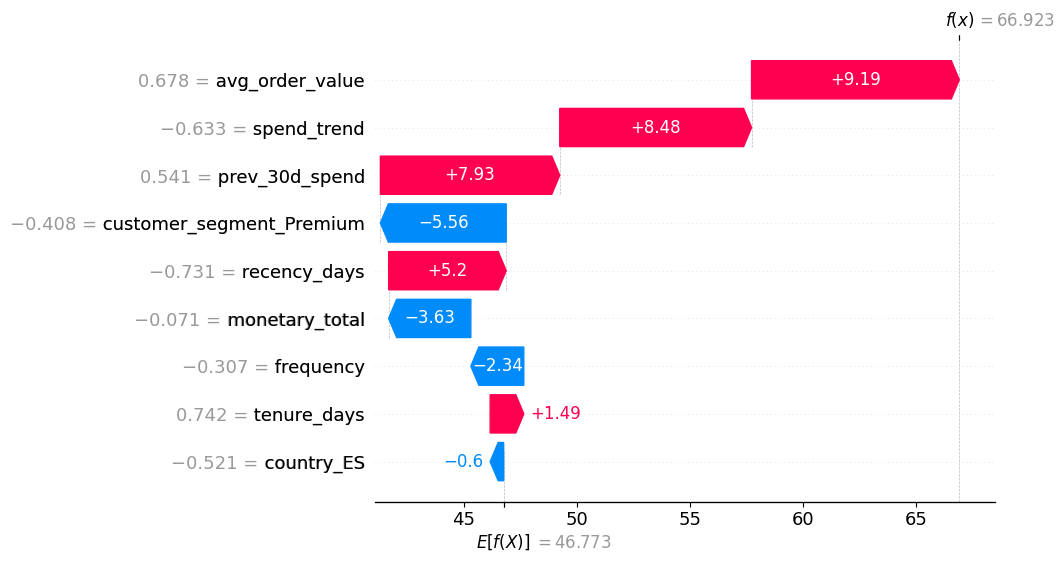

Exception ignored in: <function ResourceTracker.__del__ at 0x104e632e0>
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.12/3.12.11/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/homebrew/Cellar/python@3.12/3.12.11/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/opt/homebrew/Cellar/python@3.12/3.12.11/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106e132e0>
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.12/3.12.11/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/homebrew/Cellar/python@3.12/3.12.11/Frameworks/Python.framework/

In [ ]:
# ---------------------------------------------------------------------------
# SHAP explanations for the tuned Random Forest (showcase)
# ---------------------------------------------------------------------------

# SHAP can be a heavy dependency; we import it lazily and give a helpful message if missing.
try:
    import shap
except ImportError as e:
    raise ImportError(
        "shap is not installed. Install it with `pip install shap` in your environment "
        "(ideally in the same venv as this notebook)."
    ) from e

# For tree-based models, TreeExplainer is efficient
explainer = shap.TreeExplainer(best_model)

# Use a subset of the training data for speed (SHAP can be expensive on full data)
X_shap = X_train_sel.copy()
if len(X_shap) > 500:
    X_shap = X_shap.sample(500, random_state=SEED)

# Compute SHAP values: same shape as X_shap (rows × features)
shap_values = explainer(X_shap)

# Global summary (beeswarm) — which features matter most, and how
shap.plots.beeswarm(shap_values, max_display=15)

# Optional: inspect a single example (local explanation)
# Pick one row and show how features push the prediction up or down
idx_example = X_shap.index[0]
shap.plots.waterfall(shap_values[X_shap.index.get_loc(idx_example)], max_display=15)

## Section 10 — Summary

**Takeaways:**

- **Baseline first** — Always compare against a simple baseline (e.g. mean, linear model) to ensure your pipeline adds value.
- **Use CV for comparison** — Cross-validation gives more stable performance estimates than a single split when comparing models.
- **Learning curves** — Plot train vs validation error (e.g. vs training set size) to diagnose underfitting, overfitting, and whether more data would help.
- **Train/val development & early stopping** — For iterative models, monitor training vs validation error over iterations and stop when validation is best (or use patience) instead of overfitting.
- **Tune carefully** — Hyperparameter tuning is done on the training/validation data only; avoid peeking at the test set.
- **Feature selection after tuning** — After we have a chosen, tuned model, we select features on the training set only (e.g. via the model's importance); the final model and test evaluation use only the selected features.
- **Test set once** — Evaluate the final chosen model on the held-out test set only once, and report those metrics as your generalization estimate.
- **Interpretability next** — Feature importance from trees is a starting point; more robust methods (permutation importance, SHAP) will be covered in a follow-up session.